# Camera Calibration using Checkerboard Images

**Tujuan:** Melakukan kalibrasi kamera menggunakan pola checkerboard untuk mendapatkan:
- Camera Intrinsic Matrix (K)
- Distortion Parameters
- Reprojection Error
- Undistorted Image

---

**Konsep Dasar:**

Kalibrasi kamera adalah proses menemukan parameter internal kamera (intrinsic) dan parameter lensa (distorsi). Parameter ini diperlukan untuk memperbaiki gambar yang terdistorsi akibat lensa kamera.

**Camera Intrinsic Matrix (K):**
```
K = | fx   0   cx |
    |  0  fy   cy |
    |  0   0    1 |
```
- `fx`, `fy` : focal length dalam satuan pixel
- `cx`, `cy` : koordinat principal point (pusat optik gambar)

**Distortion Parameters:** `[k1, k2, p1, p2, k3]`
- `k1, k2, k3` : radial distortion coefficients
- `p1, p2`     : tangential distortion coefficients

## Step 1: Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 4.13.0
NumPy version: 2.1.3


## Step 2: Siapkan Folder untuk Menyimpan Gambar Checkerboard

Kita akan membuat folder `checkerboard_images/` untuk menyimpan 15 gambar checkerboard yang akan digunakan untuk kalibrasi.

In [2]:
# Buat folder untuk menyimpan gambar checkerboard
save_dir = "checkerboard_images"
os.makedirs(save_dir, exist_ok=True)
print(f"Folder '{save_dir}' siap digunakan.")

Folder 'checkerboard_images' siap digunakan.


## Step 3: Generate 15 Gambar Checkerboard Sintetis

Karena kita tidak memiliki kamera fisik, kita akan **men-generate gambar checkerboard secara programatik** menggunakan transformasi perspektif.

Setiap gambar akan memiliki:
- Rotasi yang berbeda
- Distorsi perspektif yang berbeda
- Posisi yang berbeda

Ini mensimulasikan kondisi pengambilan gambar dari sudut yang berbeda-beda, yang merupakan syarat utama kalibrasi kamera yang baik.

In [3]:
def generate_checkerboard(rows=6, cols=9, square_size=80):
    """
    Membuat gambar checkerboard dasar.
    
    rows        : jumlah kotak secara vertikal
    cols        : jumlah kotak secara horizontal
    square_size : ukuran setiap kotak dalam pixel
    """
    height = rows * square_size
    width  = cols * square_size
    img = np.zeros((height, width), dtype=np.uint8)
    
    for r in range(rows):
        for c in range(cols):
            if (r + c) % 2 == 0:
                y1, y2 = r * square_size, (r + 1) * square_size
                x1, x2 = c * square_size, (c + 1) * square_size
                img[y1:y2, x1:x2] = 255
    
    return img


def apply_perspective(img, strength=0.3, seed=0):
    """
    Menerapkan transformasi perspektif acak pada gambar.
    Ini mensimulasikan pengambilan gambar dari sudut yang berbeda.
    
    strength : seberapa besar distorsi perspektif (0.0 - 0.5)
    seed     : random seed untuk reproduktibilitas
    """
    np.random.seed(seed)
    h, w = img.shape[:2]
    
    # Titik sudut asli
    src = np.float32([
        [0, 0],
        [w - 1, 0],
        [w - 1, h - 1],
        [0, h - 1]
    ])
    
    # Titik sudut tujuan dengan offset acak
    offset = np.random.uniform(-strength, strength, (4, 2)) * np.array([w, h])
    dst = np.clip(src + offset, 0, [w - 1, h - 1]).astype(np.float32)
    
    M = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(img, M, (w, h), borderValue=128)
    
    return warped


def add_noise_and_blur(img, seed=0):
    """
    Menambahkan noise Gaussian dan sedikit blur untuk mensimulasikan
    kondisi kamera nyata.
    """
    np.random.seed(seed)
    noise = np.random.normal(0, 5, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    blurred = cv2.GaussianBlur(noisy, (3, 3), 0.5)
    return blurred


# --- Generate dan simpan 15 gambar checkerboard ---
print("Generating 15 checkerboard images...")
print("="*50)

checkerboard_base = generate_checkerboard(rows=6, cols=9, square_size=80)

# Parameter perspektif berbeda untuk setiap gambar
perspective_strengths = [
    0.05, 0.08, 0.10, 0.12, 0.15,
    0.08, 0.12, 0.06, 0.10, 0.14,
    0.09, 0.11, 0.07, 0.13, 0.10
]

for i in range(15):
    # Terapkan perspektif yang berbeda tiap gambar
    img_warped = apply_perspective(
        checkerboard_base,
        strength=perspective_strengths[i],
        seed=i * 7
    )
    
    # Tambahkan noise kecil dan blur
    img_final = add_noise_and_blur(img_warped, seed=i)
    
    # Simpan sebagai gambar grayscale
    filename = os.path.join(save_dir, f"checkerboard_{i+1:02d}.jpg")
    cv2.imwrite(filename, img_final)
    print(f"  [{i+1:2d}/15] Saved: {filename}")

print("="*50)
print(f"Selesai! 15 gambar disimpan di folder '{save_dir}'")

Generating 15 checkerboard images...
  [ 1/15] Saved: checkerboard_images\checkerboard_01.jpg
  [ 2/15] Saved: checkerboard_images\checkerboard_02.jpg
  [ 3/15] Saved: checkerboard_images\checkerboard_03.jpg
  [ 4/15] Saved: checkerboard_images\checkerboard_04.jpg
  [ 5/15] Saved: checkerboard_images\checkerboard_05.jpg
  [ 6/15] Saved: checkerboard_images\checkerboard_06.jpg
  [ 7/15] Saved: checkerboard_images\checkerboard_07.jpg
  [ 8/15] Saved: checkerboard_images\checkerboard_08.jpg
  [ 9/15] Saved: checkerboard_images\checkerboard_09.jpg
  [10/15] Saved: checkerboard_images\checkerboard_10.jpg
  [11/15] Saved: checkerboard_images\checkerboard_11.jpg
  [12/15] Saved: checkerboard_images\checkerboard_12.jpg
  [13/15] Saved: checkerboard_images\checkerboard_13.jpg
  [14/15] Saved: checkerboard_images\checkerboard_14.jpg
  [15/15] Saved: checkerboard_images\checkerboard_15.jpg
Selesai! 15 gambar disimpan di folder 'checkerboard_images'


## Step 4: Tampilkan Gambar Checkerboard

Lihat preview semua 15 gambar checkerboard yang sudah di-generate.

Total gambar ditemukan: 15


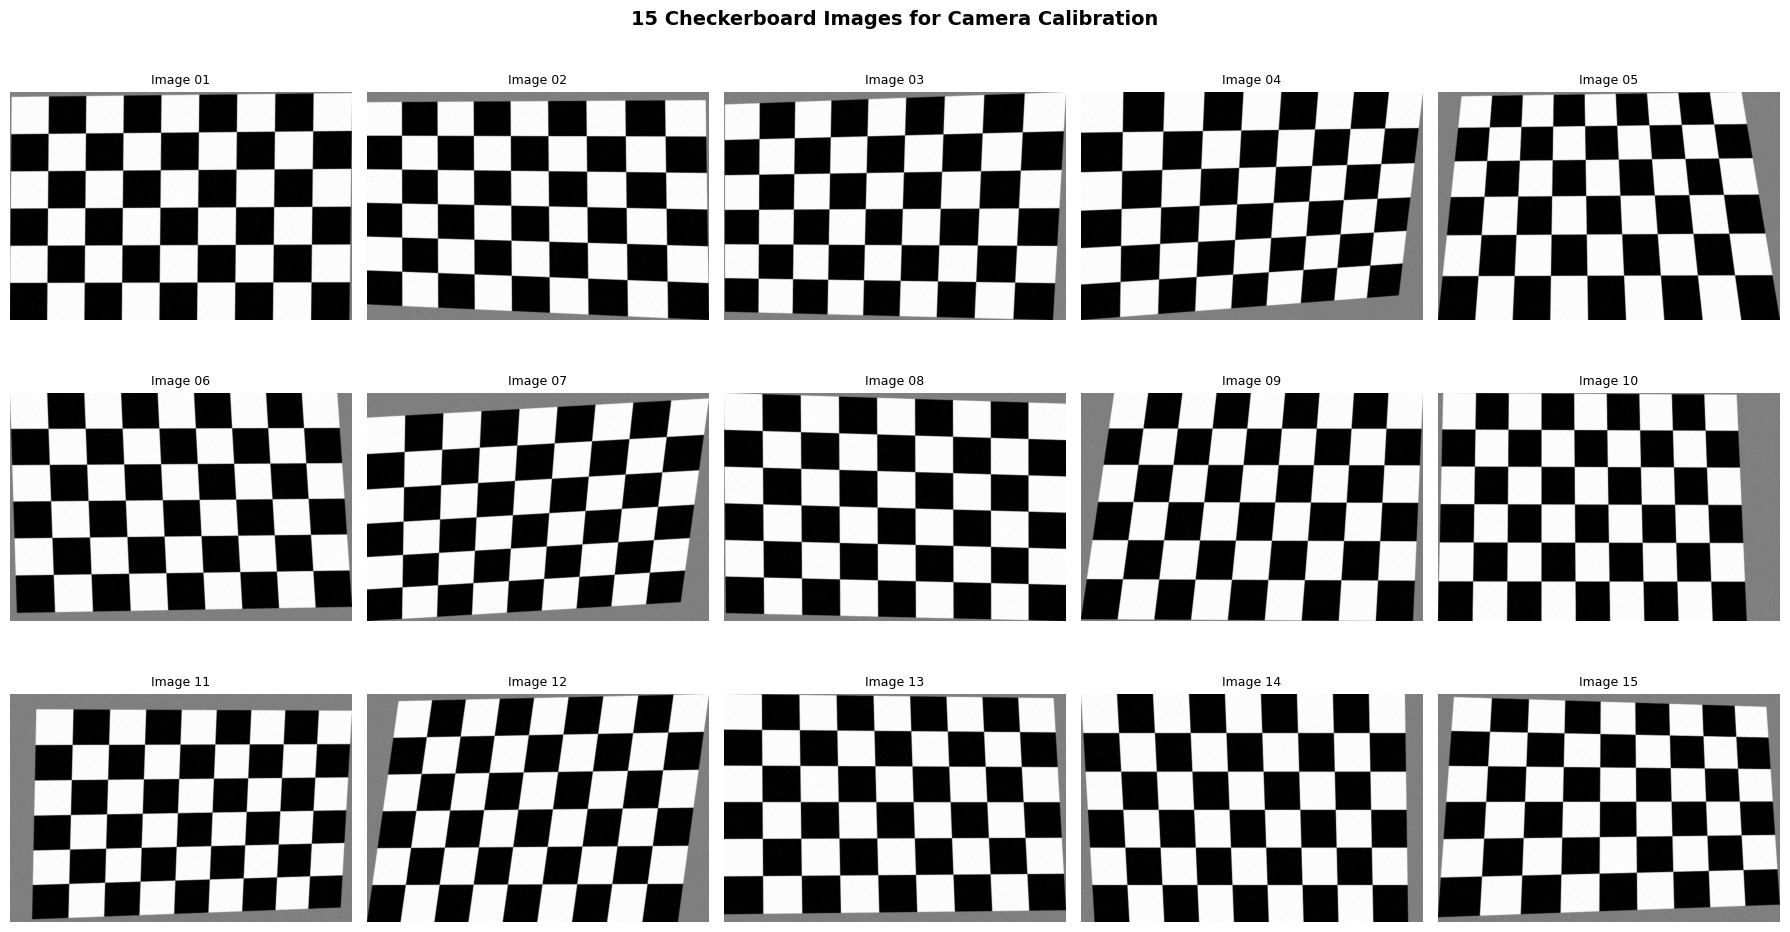

Preview tersimpan: all_checkerboard_images.png


In [4]:
image_files = sorted([
    os.path.join(save_dir, f)
    for f in os.listdir(save_dir)
    if f.endswith(('.jpg', '.png', '.jpeg'))
])

print(f"Total gambar ditemukan: {len(image_files)}")

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle("15 Checkerboard Images for Camera Calibration", fontsize=14, fontweight='bold')

for idx, (ax, filepath) in enumerate(zip(axes.flatten(), image_files)):
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Image {idx+1:02d}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig("all_checkerboard_images.png", dpi=100, bbox_inches='tight')
plt.show()
print("Preview tersimpan: all_checkerboard_images.png")

## Step 5: Deteksi Corner pada Setiap Gambar

Pada checkerboard dengan ukuran 9x6 kotak, terdapat **(9-1) x (6-1) = 8 x 5 = 40 inner corners** (titik sudut dalam).

OpenCV menggunakan fungsi `cv2.findChessboardCorners()` untuk mendeteksi titik-titik ini secara otomatis, lalu `cv2.cornerSubPix()` untuk meningkatkan akurasi deteksi hingga level sub-pixel.

In [5]:
# --- Parameter checkerboard ---
# Inner corners = (cols-1) x (rows-1) = 8 x 5
CHECKERBOARD = (8, 5)
SQUARE_SIZE = 1.0  # Ukuran kotak dalam satuan nyata (misal: cm atau mm)

# Kriteria untuk sub-pixel corner refinement
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,    # max iterations
    0.001  # epsilon (akurasi)
)

# --- Buat titik 3D objek (world coordinates) ---
# Titik-titik ini sama untuk semua gambar karena checkerboard selalu flat
# Format: (0,0,0), (1,0,0), (2,0,0), ..., (7,4,0)
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

# --- Kumpulkan titik objek dan titik gambar ---
objpoints = []  # Titik 3D di dunia nyata
imgpoints = []  # Titik 2D di gambar
valid_images = []  # Simpan daftar gambar yang berhasil terdeteksi

print(f"Konfigurasi Checkerboard: {CHECKERBOARD[0]}x{CHECKERBOARD[1]} inner corners")
print(f"Total gambar  : {len(image_files)}")
print("="*60)

for filepath in image_files:
    img = cv2.imread(filepath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Deteksi corners
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    
    name = os.path.basename(filepath)
    
    if ret:
        # Refinement ke sub-pixel untuk akurasi lebih tinggi
        corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        
        objpoints.append(objp)
        imgpoints.append(corners_refined)
        valid_images.append(filepath)
        print(f"  [OK] {name} - {len(corners_refined)} corners detected")
    else:
        print(f"  [FAIL] {name} - corners tidak terdeteksi")

print("="*60)
print(f"Berhasil : {len(valid_images)}/{len(image_files)} gambar")

img_shape = gray.shape[::-1]  # (width, height)

Konfigurasi Checkerboard: 8x5 inner corners
Total gambar  : 15
  [OK] checkerboard_01.jpg - 40 corners detected
  [OK] checkerboard_02.jpg - 40 corners detected
  [OK] checkerboard_03.jpg - 40 corners detected
  [OK] checkerboard_04.jpg - 40 corners detected
  [OK] checkerboard_05.jpg - 40 corners detected
  [OK] checkerboard_06.jpg - 40 corners detected
  [OK] checkerboard_07.jpg - 40 corners detected
  [OK] checkerboard_08.jpg - 40 corners detected
  [OK] checkerboard_09.jpg - 40 corners detected
  [OK] checkerboard_10.jpg - 40 corners detected
  [OK] checkerboard_11.jpg - 40 corners detected
  [OK] checkerboard_12.jpg - 40 corners detected
  [OK] checkerboard_13.jpg - 40 corners detected
  [OK] checkerboard_14.jpg - 40 corners detected
  [OK] checkerboard_15.jpg - 40 corners detected
Berhasil : 15/15 gambar


## Step 6: Visualisasi Corner Detection

Tampilkan contoh hasil deteksi corner pada beberapa gambar.

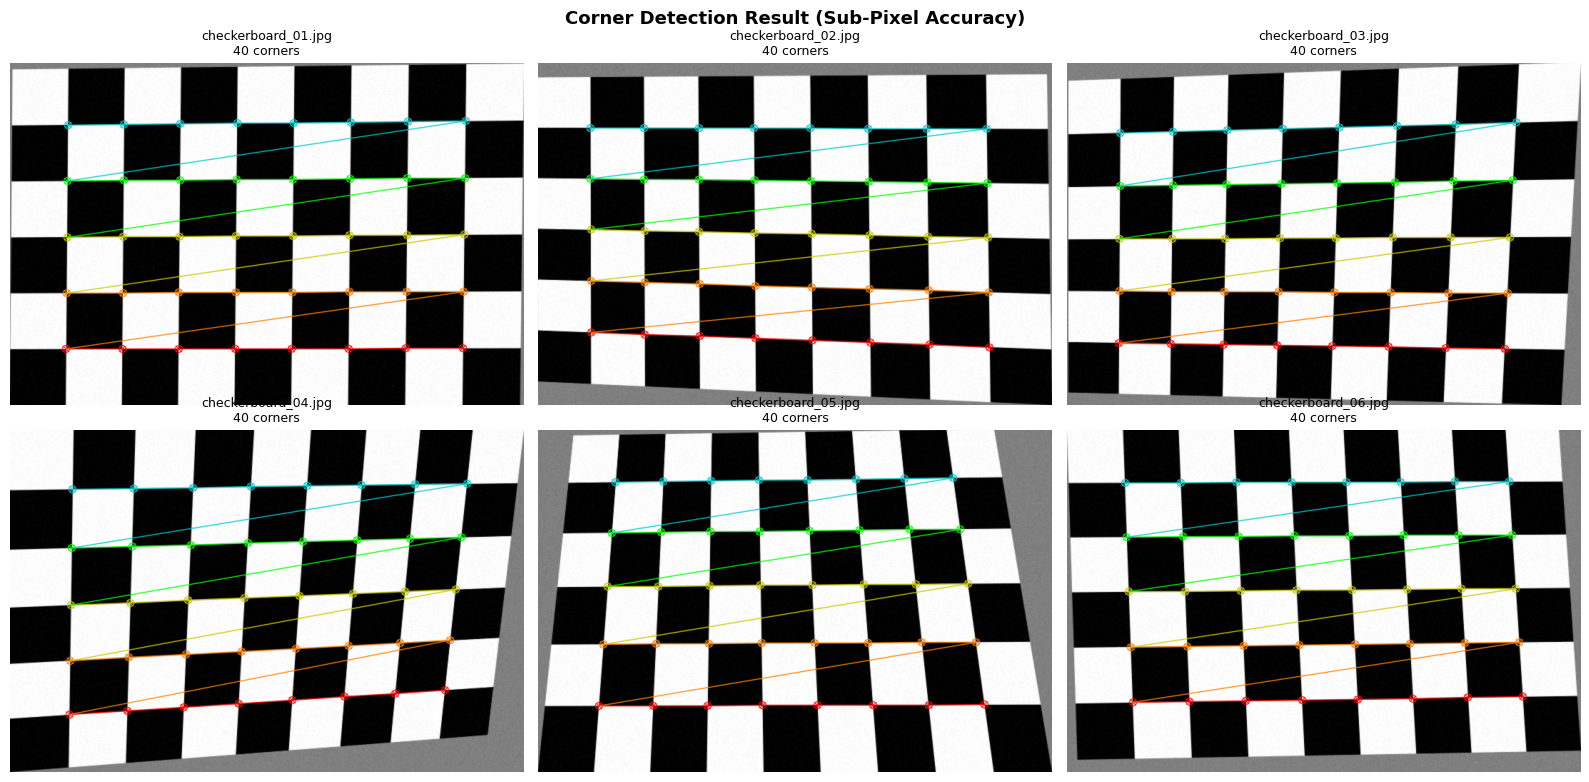

Hasil tersimpan: corner_detection.png


In [6]:
# Tampilkan 6 gambar pertama yang berhasil terdeteksi
n_show = min(6, len(valid_images))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Corner Detection Result (Sub-Pixel Accuracy)", fontsize=13, fontweight='bold')

for idx, (ax, filepath) in enumerate(zip(axes.flatten(), valid_images[:n_show])):
    img = cv2.imread(filepath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
    
    # Gambar corners pada gambar
    img_drawn = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners_refined, ret)
    img_rgb = cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img_rgb)
    ax.set_title(f"{os.path.basename(filepath)}\n{len(corners_refined)} corners", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig("corner_detection.png", dpi=100, bbox_inches='tight')
plt.show()
print("Hasil tersimpan: corner_detection.png")

## Step 7: Jalankan Kalibrasi Kamera (Calibration Pipeline)

Fungsi `cv2.calibrateCamera()` menggunakan algoritma Zhang's method untuk mengestimasi:
- **Camera Matrix (K):** Parameter intrinsik kamera
- **Distortion Coefficients:** Koefisien distorsi lensa
- **Rotation & Translation Vectors:** Posisi kamera relatif terhadap checkerboard

In [7]:
print("Menjalankan kalibrasi kamera...")
print("="*60)

ret_calib, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,   # Titik 3D objek
    imgpoints,   # Titik 2D gambar
    img_shape,   # Ukuran gambar (width, height)
    None,        # Camera matrix awal (None = estimasi otomatis)
    None         # Distortion coefficients awal
)

print(f"Kalibrasi selesai!")
print(f"Jumlah gambar digunakan : {len(valid_images)}")
print(f"Ukuran gambar           : {img_shape[0]}x{img_shape[1]} pixel")

Menjalankan kalibrasi kamera...
Kalibrasi selesai!
Jumlah gambar digunakan : 15
Ukuran gambar           : 720x480 pixel


## Step 8: Report - Camera Intrinsic Matrix (K) dan Distortion Parameters

Tampilkan hasil kalibrasi secara lengkap dan terstruktur.

In [8]:
print("=" * 60)
print("         CALIBRATION REPORT")
print("=" * 60)

# --- Camera Intrinsic Matrix K ---
print("\n[1] CAMERA INTRINSIC MATRIX (K)")
print("-" * 40)
print(f"\n{camera_matrix}")

fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

print(f"\nDetail:")
print(f"  fx (focal length X) = {fx:.4f} px")
print(f"  fy (focal length Y) = {fy:.4f} px")
print(f"  cx (principal point X) = {cx:.4f} px")
print(f"  cy (principal point Y) = {cy:.4f} px")

# --- Distortion Parameters ---
print("\n[2] DISTORTION PARAMETERS")
print("-" * 40)
print(f"\n{dist_coeffs}")

k1, k2, p1, p2, k3 = dist_coeffs[0]
print(f"\nDetail:")
print(f"  k1 (radial distortion 1) = {k1:.6f}")
print(f"  k2 (radial distortion 2) = {k2:.6f}")
print(f"  p1 (tangential distortion 1) = {p1:.6f}")
print(f"  p2 (tangential distortion 2) = {p2:.6f}")
print(f"  k3 (radial distortion 3) = {k3:.6f}")

print("\n" + "=" * 60)

         CALIBRATION REPORT

[1] CAMERA INTRINSIC MATRIX (K)
----------------------------------------

[[1.28707115e+04 0.00000000e+00 3.86524748e+02]
 [0.00000000e+00 1.00974464e+04 2.32074663e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Detail:
  fx (focal length X) = 12870.7115 px
  fy (focal length Y) = 10097.4464 px
  cx (principal point X) = 386.5247 px
  cy (principal point Y) = 232.0747 px

[2] DISTORTION PARAMETERS
----------------------------------------

[[ 2.34200526e+01 -4.12725524e+04  1.44319075e-01 -7.74532554e-02
  -1.18771459e+02]]

Detail:
  k1 (radial distortion 1) = 23.420053
  k2 (radial distortion 2) = -41272.552425
  p1 (tangential distortion 1) = 0.144319
  p2 (tangential distortion 2) = -0.077453
  k3 (radial distortion 3) = -118.771459



## Step 9: Hitung Reprojection Error

**Reprojection Error** mengukur seberapa akurat hasil kalibrasi. 

Caranya: titik 3D objek di-project ulang ke gambar menggunakan parameter kalibrasi, lalu dibandingkan dengan titik 2D yang terdeteksi. Semakin kecil error, semakin akurat kalibrasi.

- Error < 0.5 pixel  : Sangat baik
- Error < 1.0 pixel  : Baik
- Error > 1.0 pixel  : Perlu lebih banyak gambar atau gambar lebih berkualitas

In [9]:
print("=" * 60)
print("         REPROJECTION ERROR REPORT")
print("=" * 60)

per_image_errors = []

for i, (objp_i, imgp_i, rvec, tvec) in enumerate(zip(objpoints, imgpoints, rvecs, tvecs)):
    # Project titik 3D kembali ke 2D menggunakan parameter kalibrasi
    projected_points, _ = cv2.projectPoints(objp_i, rvec, tvec, camera_matrix, dist_coeffs)
    
    # Hitung error (jarak Euclidean antara titik asli dan titik yang di-project)
    error = cv2.norm(imgp_i, projected_points, cv2.NORM_L2) / len(projected_points)
    per_image_errors.append(error)
    
    img_name = os.path.basename(valid_images[i])
    print(f"  Image {i+1:02d} ({img_name}): {error:.4f} px")

mean_error = np.mean(per_image_errors)

print("-" * 60)
print(f"  Mean Reprojection Error : {mean_error:.4f} px")
print(f"  Min Error               : {min(per_image_errors):.4f} px")
print(f"  Max Error               : {max(per_image_errors):.4f} px")

# Penilaian kualitas
print()
if mean_error < 0.5:
    print("  Kualitas Kalibrasi: SANGAT BAIK (error < 0.5 px)")
elif mean_error < 1.0:
    print("  Kualitas Kalibrasi: BAIK (error < 1.0 px)")
else:
    print("  Kualitas Kalibrasi: PERLU PENINGKATAN (error > 1.0 px)")

print("=" * 60)

         REPROJECTION ERROR REPORT
  Image 01 (checkerboard_01.jpg): 0.2295 px
  Image 02 (checkerboard_02.jpg): 0.4084 px
  Image 03 (checkerboard_03.jpg): 0.5934 px
  Image 04 (checkerboard_04.jpg): 0.8154 px
  Image 05 (checkerboard_05.jpg): 1.3160 px
  Image 06 (checkerboard_06.jpg): 0.1810 px
  Image 07 (checkerboard_07.jpg): 0.7036 px
  Image 08 (checkerboard_08.jpg): 0.3099 px
  Image 09 (checkerboard_09.jpg): 0.4743 px
  Image 10 (checkerboard_10.jpg): 0.4036 px
  Image 11 (checkerboard_11.jpg): 0.2671 px
  Image 12 (checkerboard_12.jpg): 0.1573 px
  Image 13 (checkerboard_13.jpg): 0.1959 px
  Image 14 (checkerboard_14.jpg): 0.4795 px
  Image 15 (checkerboard_15.jpg): 0.7159 px
------------------------------------------------------------
  Mean Reprojection Error : 0.4834 px
  Min Error               : 0.1573 px
  Max Error               : 1.3160 px

  Kualitas Kalibrasi: SANGAT BAIK (error < 0.5 px)


## Step 10: Visualisasi Reprojection Error per Gambar

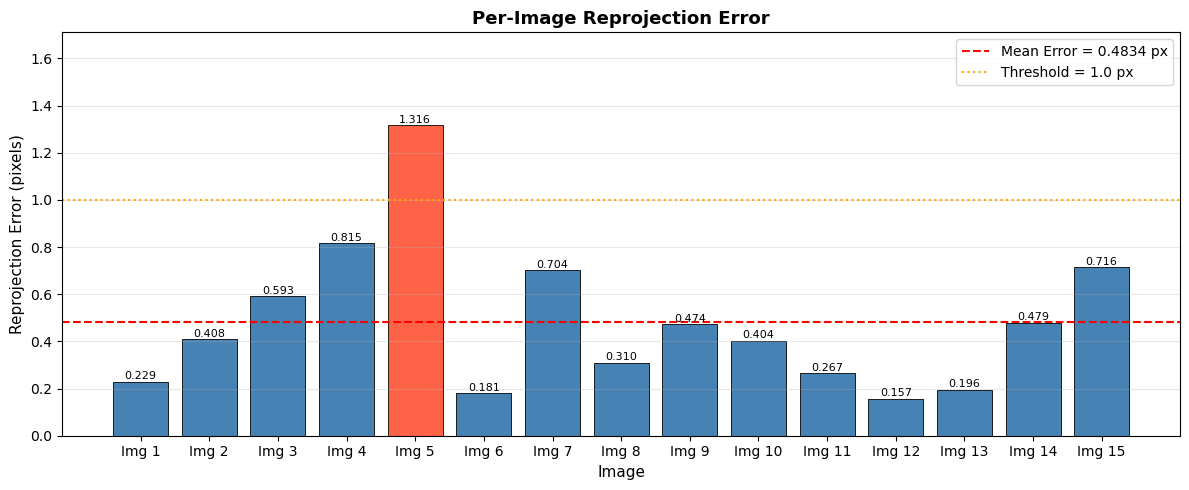

Grafik tersimpan: reprojection_error.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

image_labels = [f"Img {i+1}" for i in range(len(per_image_errors))]
colors = ['steelblue' if e < 1.0 else 'tomato' for e in per_image_errors]

bars = ax.bar(image_labels, per_image_errors, color=colors, edgecolor='black', linewidth=0.6)

# Garis referensi mean error
ax.axhline(mean_error, color='red', linestyle='--', linewidth=1.5, label=f'Mean Error = {mean_error:.4f} px')
ax.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Threshold = 1.0 px')

# Tambahkan nilai di atas setiap bar
for bar, val in zip(bars, per_image_errors):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Image", fontsize=11)
ax.set_ylabel("Reprojection Error (pixels)", fontsize=11)
ax.set_title("Per-Image Reprojection Error", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(per_image_errors) * 1.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("reprojection_error.png", dpi=100, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: reprojection_error.png")

## Step 11: Undistort Test Image

Setelah mendapatkan parameter kalibrasi, kita bisa **mengoreksi distorsi** pada gambar yang baru.

Fungsi `cv2.undistort()` menerapkan inverse dari model distorsi untuk menghasilkan gambar yang bebas distorsi.

Kita juga menggunakan `cv2.getOptimalNewCameraMatrix()` untuk mendapatkan camera matrix yang dioptimalkan agar tidak ada informasi gambar yang hilang.

In [11]:
# Gunakan gambar pertama sebagai test image
test_image_path = valid_images[0]
test_img = cv2.imread(test_image_path)
h, w = test_img.shape[:2]

print(f"Test image  : {os.path.basename(test_image_path)}")
print(f"Ukuran      : {w}x{h} pixel")

# Hitung optimal camera matrix agar gambar tidak ter-crop berlebihan
# alpha=1 : tampilkan semua pixel (termasuk area hitam) 
# alpha=0 : crop area hitam hasil undistort
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (w, h), alpha=1
)

# Undistort gambar
undistorted_img = cv2.undistort(
    test_img,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix
)

# Simpan hasil undistorted
cv2.imwrite("test_image_undistorted.jpg", undistorted_img)
print("Hasil undistorted tersimpan: test_image_undistorted.jpg")

Test image  : checkerboard_01.jpg
Ukuran      : 720x480 pixel
Hasil undistorted tersimpan: test_image_undistorted.jpg


## Step 12: Perbandingan Gambar Original vs Undistorted

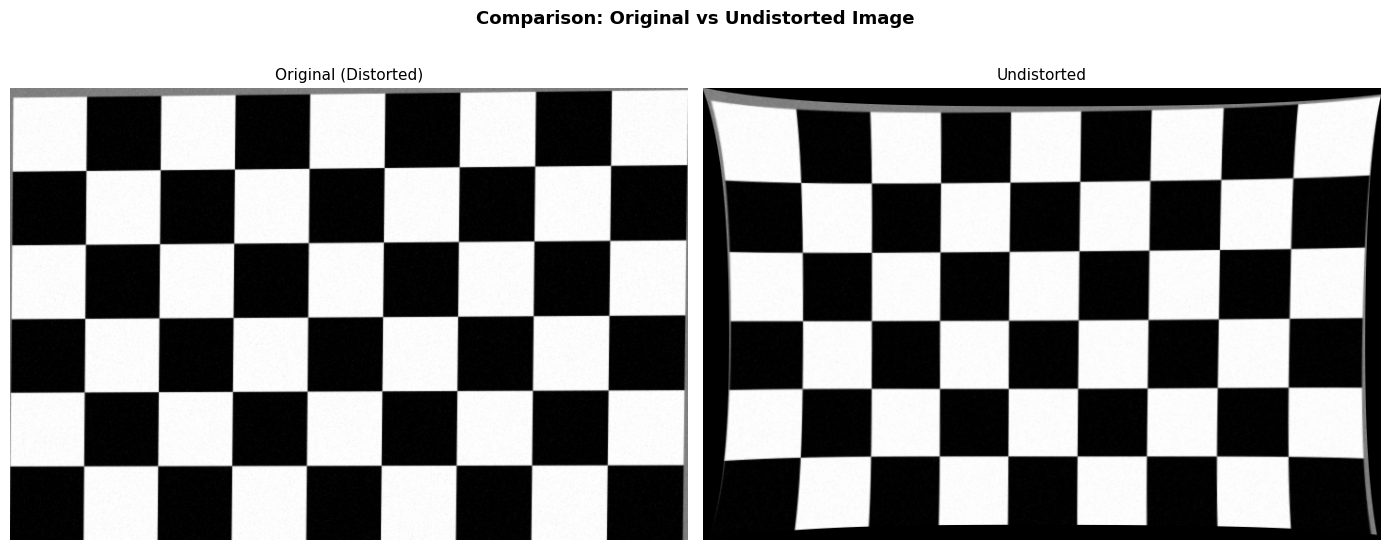

Perbandingan tersimpan: original_vs_undistorted.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparison: Original vs Undistorted Image", fontsize=13, fontweight='bold')

# Gambar original
axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB), cmap='gray')
axes[0].set_title("Original (Distorted)", fontsize=11)
axes[0].axis('off')

# Gambar setelah undistort
axes[1].imshow(cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB), cmap='gray')
axes[1].set_title("Undistorted", fontsize=11)
axes[1].axis('off')

plt.tight_layout()
plt.savefig("original_vs_undistorted.png", dpi=100, bbox_inches='tight')
plt.show()
print("Perbandingan tersimpan: original_vs_undistorted.png")

## Step 13: Ringkasan Hasil Kalibrasi

Tampilkan ringkasan semua hasil kalibrasi dalam satu laporan akhir.

In [13]:
print("=" * 65)
print("                  CAMERA CALIBRATION SUMMARY")
print("=" * 65)

print(f"\n  Images used for calibration : {len(valid_images)} / 15")
print(f"  Checkerboard pattern        : {CHECKERBOARD[0]}x{CHECKERBOARD[1]} inner corners")
print(f"  Image resolution            : {w}x{h} pixels")

print("\n--- Camera Intrinsic Matrix (K) ---")
print(f"  fx = {fx:.2f} px  |  fy = {fy:.2f} px")
print(f"  cx = {cx:.2f} px  |  cy = {cy:.2f} px")

print("\n--- Distortion Coefficients ---")
print(f"  k1 = {k1:+.6f}  (radial 1)")
print(f"  k2 = {k2:+.6f}  (radial 2)")
print(f"  p1 = {p1:+.6f}  (tangential 1)")
print(f"  p2 = {p2:+.6f}  (tangential 2)")
print(f"  k3 = {k3:+.6f}  (radial 3)")

print("\n--- Reprojection Error ---")
print(f"  Mean Error : {mean_error:.4f} pixels")

if mean_error < 0.5:
    quality = "Sangat Baik"
elif mean_error < 1.0:
    quality = "Baik"
else:
    quality = "Perlu Peningkatan"

print(f"  Kualitas   : {quality}")

print("\n--- Output Files ---")
print("  all_checkerboard_images.png   : Preview 15 gambar checkerboard")
print("  corner_detection.png          : Hasil deteksi corner")
print("  reprojection_error.png        : Grafik reprojection error")
print("  original_vs_undistorted.png   : Perbandingan original vs undistorted")
print("  test_image_undistorted.jpg    : Gambar hasil undistort")

print("\n" + "=" * 65)

                  CAMERA CALIBRATION SUMMARY

  Images used for calibration : 15 / 15
  Checkerboard pattern        : 8x5 inner corners
  Image resolution            : 720x480 pixels

--- Camera Intrinsic Matrix (K) ---
  fx = 12870.71 px  |  fy = 10097.45 px
  cx = 386.52 px  |  cy = 232.07 px

--- Distortion Coefficients ---
  k1 = +23.420053  (radial 1)
  k2 = -41272.552425  (radial 2)
  p1 = +0.144319  (tangential 1)
  p2 = -0.077453  (tangential 2)
  k3 = -118.771459  (radial 3)

--- Reprojection Error ---
  Mean Error : 0.4834 pixels
  Kualitas   : Sangat Baik

--- Output Files ---
  all_checkerboard_images.png   : Preview 15 gambar checkerboard
  corner_detection.png          : Hasil deteksi corner
  reprojection_error.png        : Grafik reprojection error
  original_vs_undistorted.png   : Perbandingan original vs undistorted
  test_image_undistorted.jpg    : Gambar hasil undistort

